Agents

An Agent is a model calling tools in a loop until a given task is complete.

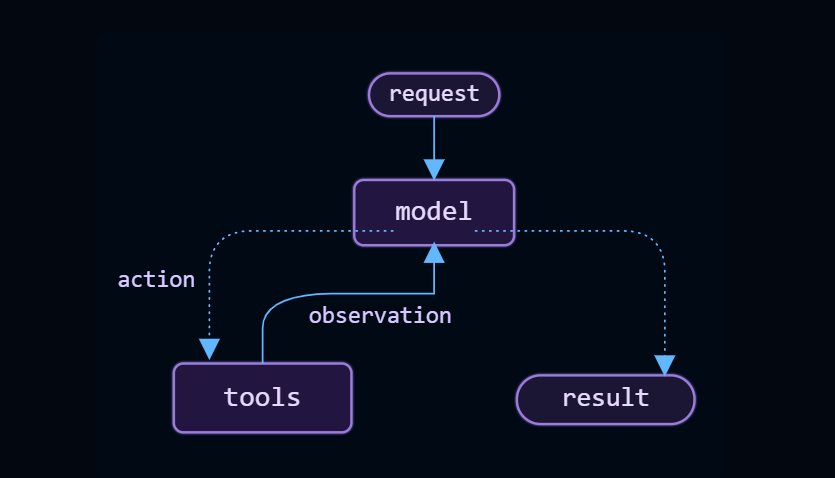

Agent = Model + Harness

The job of a harness: get the model the right context at the right time for the given task.

A harness is everything around that loop: the model, its prompt, its tools, and any middleware that shapes its behaviour.

create_agent is a highly configurable harness. At its simplest, you can create one with:

``` python
from langchain.agents import create_agent
agent = create_agent(model="google_genai:gemini-3.5-flash", tools=tools)
```

Building on that, we can configure the basics directly with the model=, tools=, and system_prompt= parameters. For more advanced capabilities, extend the harness with middleware.


#### Core Components 

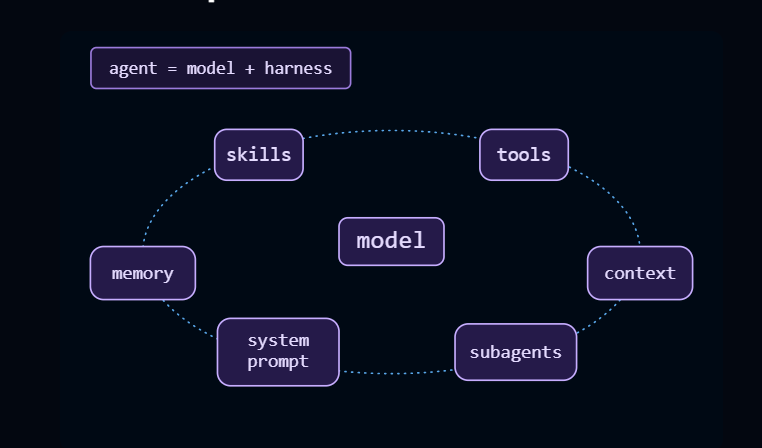



**Model**:

Pass a model identifier string ("provider:model") or an initialized model instance to select the model for your agent.

``` python 
from langchain.agents import create_agent
agent = create_agent(model="google_genai:gemini-3.5-flash", tools=tools)
```

**Tools**

To provide the agent with tools, pass any Python callable, LangChain tool, or tool dict.

``` python
from langchain.agents import create_agent
from langchain.tools import tool

@tool
def search(query: str) -> str:
    """Search for information."""
    return f"Results for: {query}"

agent = create_agent(model="google_genai:gemini-3.5-flash", tools=[search])
```

**System prompt**

Shape how the agent approaches tasks. The system prompt parameter accepts a string or SystemMessage. For dynamic prompts at runtime, use middleware.

``` python
agent = create_agent(
    model="google_genai:gemini-3.5-flash",
    tools=tools,
    system_prompt="You are a helpful assistant. Be concise and accurate.",
)
```

**Structured Output**

Return a validated schema from the agent using response_format=.

``` python
from pydantic import BaseModel
from langchain.agents import create_agent

class Answer(BaseModel):
    summary: str
    confidence: float


agent = create_agent(model="google_genai:gemini-3.5-flash", tools=tools, response_format=Answer)
result = agent.invoke({"messages": [{"role": "user", "content": "Summarize AI trends"}]})
result["structured_response"]  # Answer(summary=..., confidence=...)
```



**Invocation**

we can invoke an agent with a message. behind the states that passes an update to the agents state. All agents include a sequence of messages in their state, to invoke the agent pass a new message with thread_id so tha agent can perssit and resume the conversation history.

``` python 
from langchain.agents import create_agent
from langchain_core.utils.uuid import uuid7
from langgraph.checkpoint.memory import InMemorySaver

agent = create_agent(
    model="google_genai:gemini-3.5-flash",
    tools=[],
    checkpointer=InMemorySaver(),
)

config = {"configurable": {"thread_id": str(uuid7())}}

result = agent.invoke(
    {"messages": [{"role": "user", "content": "What's the weather in San Francisco?"}]},
    config=config,
)

# A follow-up turn on the same conversation: reuse the same thread_id to keep history
result = agent.invoke(
    {"messages": [{"role": "user", "content": "What about tomorrow?"}]},
    config=config,
)
```

Note : Persisting Conversation History with thread_id requires the agent to be configured with a check pointer 

If you also need to pass per-run configuration (such as a user ID, API keys, or feature flags) to tools and middleware, pass it as context alongside config. Define the shape of that data with context_schema and access it through runtime.context:

``` python
from dataclasses import dataclass

from langchain.agents import create_agent
from langchain_core.utils.uuid import uuid7
from langgraph.checkpoint.memory import InMemorySaver


@dataclass
class Context:
    user_id: str


agent = create_agent(
    model="google_genai:gemini-3.5-flash",
    tools=[],
    context_schema=Context,
    checkpointer=InMemorySaver(),
)

result = agent.invoke(
    {"messages": [{"role": "user", "content": "What's the weather in San Francisco?"}]},
    config={"configurable": {"thread_id": str(uuid7())}},
    context=Context(user_id="user-123"),
)
```

thread_id scopes the conversation (message history, checkpoints), while context carries per-run data your tools and middleware read at invocation time. Both are commonly passed together.





**Streaming**

invoke returns the final reponse at the end of a run. if an agent executes multiple tool calls, users often need progress updates before completion. use streaming to surface intermediate messages and tool activity as they happen.

``` python
from langchain.messages import AIMessage, HumanMessage


stream = agent.stream_events(
    {"messages": [{"role": "user", "content": "Search for AI news and summarize the findings"}]},
    version="v3",
)
for snapshot in stream.values:
    # Each snapshot contains the full state at that point
    latest_message = snapshot["messages"][-1]
    if latest_message.content:
        if isinstance(latest_message, HumanMessage):
            print(f"User: {latest_message.content}")
        elif isinstance(latest_message, AIMessage):
            print(f"Agent: {latest_message.content}")
    elif latest_message.tool_calls:
        print(f"Calling tools: {[tc['name'] for tc in latest_message.tool_calls]}")
```

**Configure the Harness**

``create_agent`` is highly extensible. Middleware is the primitive for customization: each piece handles one concern, hooks into the agent loop at the right moment, and composes freely with any other. Take exactly what your use case needs and skip the rest.

Common patterns are prebuilt as first-class middleware.

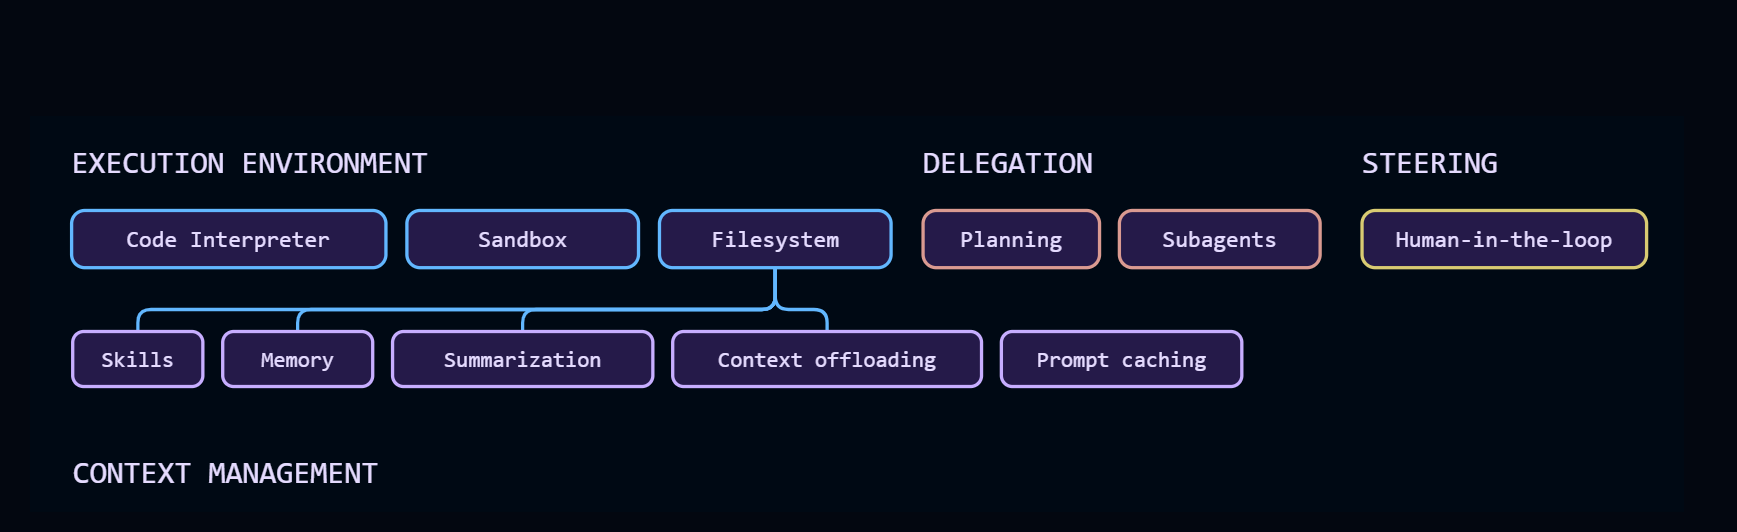


As agents take on complex work, they need support across a few key areas. The middleware ecosystem provides:

1. Excecution Environment : Tools, filesystem, sandboxes, and code Excecution
2. context management summariation, memory, skills, and prompt caching.
3. planning and deligation : Todo lists and subagents for parallel, isolated work.
4. Fault tolerance : Retries, fallbacks, and call limits.
5. guardrails : Pll detection and content controls.
6. Steering : Human-in-the-loop approval before high-impact actions

Note: "create_deep_agent" pre-assembles this stack for long-running coding and reasearch tasks(file system, summarization,subagents, and prompt caching included by defualt) 

#### Excecution Environment

Agents are especially useful when they can take action rather than just generate text. The execution environment gives the agent a workspace: tools it can call, a filesystem for reading and writing flow across turns, and code excecution for running scripts or shell commands. 

``` python
from langchain.agents import create_agent
from deepagents.backends import StateBackend
from deepagents.middleware import FilesystemMiddleware

agent = create_agent(
    model="google_genai:gemini-3.5-flash",
    tools=[search],
    middleware=[FilesystemMiddleware(backend=StateBackend())],
)
```

**Context Management**

Every Model call has fixed context window, As an agent runs, that window fills with accumulating history,tool results, and intermediate steps. Summarization compresses history before overflow hits; memory loads persistent instructions at startup so knoweldge carries across sessions; skills surface domain knoweldge on demand rather than loading everything upfront.

``` python
from deepagents.backends import StateBackend
from deepagents.middleware import FilesystemMiddleware, MemoryMiddleware, SkillsMiddleware, SummarizationMiddleware

backend = StateBackend()
model="google_genai:gemini-3.5-flash"

agent = create_agent(
    model=model,
    tools=[search],
    middleware=[
        FilesystemMiddleware(backend=backend),
        SummarizationMiddleware(model=model, backend=backend),
        MemoryMiddleware(backend=backend, sources=["./AGENTS.md"]),
        SkillsMiddleware(backend=backend, sources=["./skills/"]),
    ],
)
```

**Planning and Delegation**

Complex tasks often exceed what one context window can handle. Delegation lets the main agent break work into pieces, hand them to subagents that each run in their own isolated context, and stay focused on coordination rather than execution. Work can run in parallel; the main agent’s context stays clean.

``` python
from deepagents.backends import StateBackend
from deepagents.middleware import FilesystemMiddleware
from deepagents.middleware.subagents import SubAgentMiddleware
from langchain.agents import create_agent
from langchain.agents.middleware import TodoListMiddleware
from langchain.tools import tool


@tool
def search(query: str) -> str:
    """Search for a query and return a short summary."""
    return f"Search results for: {query}"


backend = StateBackend()

agent = create_agent(
    model="google_genai:gemini-3.5-flash",
    tools=[search],
    middleware=[
        FilesystemMiddleware(backend=backend),
        TodoListMiddleware(),
        SubAgentMiddleware(
            backend=backend,
            subagents=[
                {
                    "name": "researcher",
                    "description": "Searches and returns a structured summary.",
                    "system_prompt": "Use the search tool to research the question and summarize key points.",
                    "tools": [search],
                    "model": "anthropic:claude-sonnet-4-6",
                    "middleware": [],
                }
            ],
        ),
    ],
)
```

**Name your Agent**

Optionally use an identifier for the agent. This is especially useful when embedding the agent as a subgraph in multi-agent systems.

``` python
agent = create_agent(model="google_genai:gemini-3.5-flash", tools=tools, name="research_assistant")
```

**Fault Tolerance**

Agents in production encounter failures that rarely appear in development: rate limits, model timeouts, transient API errors. Fault tolerance middleware handles these at the infrastructure level so your tools and business logic don’t need try/catch around every call.

``` python
from langchain.agents import create_agent
from langchain.agents.middleware import ModelRetryMiddleware, ToolRetryMiddleware
from langchain.tools import tool


@tool
def search(query: str) -> str:
    """Search for a query and return a short summary."""
    return f"Search results for: {query}"


agent = create_agent(
    model="google_genai:gemini-3.5-flash",
    tools=[search],
    middleware=[
        ModelRetryMiddleware(max_retries=3),
        ToolRetryMiddleware(max_retries=2),
    ],
)
```



**Guardrails**

Some policies can't live in a prompt , they need to be enforced determistically regardless of what the model does.
guardrails intercept data as it flows through the agent loop, applying compliance rules or content policies before tool results reach the model's context. 

``` python
from langchain.agents import create_agent
from langchain.agents.middleware import PIIMiddleware
from langchain.tools import tool


@tool
def search(query: str) -> str:
    """Search for a query and return a short summary."""
    return f"Search results for: {query}"


agent = create_agent(
    model="google_genai:gemini-3.5-flash",
    tools=[search],
    middleware=[PIIMiddleware("email")],
)
```

**Steering**

Full autonomy is not always appropriate. Steering lets you place humans at specific decision points , before destructive writes, expensive api calls, or anything requiring judgement, without restructuring your agent. The agent pauses and waits, human approves, edits, or rejects; excecution continues.

``` python
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langchain.tools import tool


@tool
def search(query: str) -> str:
    """Search for a query and return a short summary."""
    return f"Search results for: {query}"


agent = create_agent(
    model="google_genai:gemini-3.5-flash",
    tools=[search],
    middleware=[HumanInTheLoopMiddleware(interrupt_on={"write_file": True})],
)
```